# MLP - Multi Layer Perceptron

In this notebook, we will implement a simple MLP to classify the MNIST dataset. The MNIST dataset consists of 28x28 pixel images of handwritten digits (0-9) and is commonly used for training various image processing systems.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# import keras
import tensorflow.keras as keras
import keras.layers as layers
import keras.optimizers as optimizers
import keras.models as models

In [4]:
LEARNING_RATE = 0.001
BATCH_SIZE = 128
N_EPOCHS = 20

In [5]:
# Load and prepare the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = x_train.astype('float32') / 255.0
X_test = x_test.astype('float32') / 255.0

In [6]:
# Create a simple dense MLP model using Sequential API
model_dense = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])

2026-03-16 14:18:11.234890: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-03-16 14:18:11.234915: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-16 14:18:11.234920: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-16 14:18:11.234934: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-16 14:18:11.234941: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [7]:
# Compile the model
model_dense.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']
)

In [8]:
# Early stopping callback to prevent overfitting
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [9]:
# Train the model
history = model_dense.fit(X_train, y_train,
                          epochs=N_EPOCHS,
                          batch_size=BATCH_SIZE,
                          validation_data=(X_test, y_test),
                          callbacks=[early_stopping]
)

Epoch 1/20


2026-03-16 14:18:11.542615: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8602 - loss: 0.5054 - val_accuracy: 0.9169 - val_loss: 0.2999
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9159 - loss: 0.3018 - val_accuracy: 0.9214 - val_loss: 0.2794
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9201 - loss: 0.2860 - val_accuracy: 0.9209 - val_loss: 0.2841
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9231 - loss: 0.2788 - val_accuracy: 0.9187 - val_loss: 0.2890
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9242 - loss: 0.2748 - val_accuracy: 0.9246 - val_loss: 0.2740
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9243 - loss: 0.2707 - val_accuracy: 0.9231 - val_loss: 0.2776
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9261 - loss: 0.2692 - val_accuracy: 0.9241 - val_loss: 0.2766
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9263 - loss: 0.2670 - val_accuracy: 0.9236 - val_

In [10]:
# Evaluate the model on the test set
loss, acc = model_dense.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy:{acc:.4f}')

Test accuracy:0.9246


In [11]:
# create a concat dataset of all the X_train and X_test
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

In [12]:
# Do a global Evaluation of the model on the entire dataset
loss, acc = model_dense.evaluate(X, y, verbose=0)
print(f'Global accuracy:{acc:.4f}')

Global accuracy:0.9259


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

2188/2188 ━━━━━━━━━━━━━━━━━━━━ 2s 771us/step


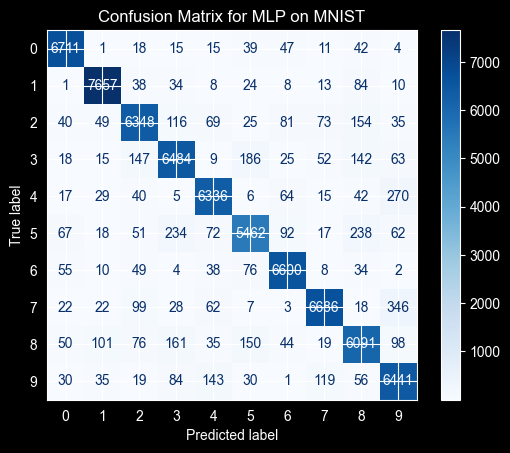

In [14]:
# Do a confusion matrix to see the performance of the model on each class
pred = model_dense.predict(X)
pred_classes = np.argmax(pred, axis=1)
cm = confusion_matrix(y, pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MLP on MNIST')
plt.show()

In [15]:
from sklearn.metrics import classification_report

# Print a classification report to see the precision, recall and f1-score for each class
report = classification_report(y, pred_classes, target_names=[str(i) for i in range(10)])
print(report)

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      6903
           1       0.96      0.97      0.97      7877
           2       0.92      0.91      0.92      6990
           3       0.90      0.91      0.91      7141
           4       0.93      0.93      0.93      6824
           5       0.91      0.87      0.89      6313
           6       0.95      0.96      0.95      6876
           7       0.95      0.92      0.93      7293
           8       0.88      0.89      0.89      6825
           9       0.88      0.93      0.90      6958

    accuracy                           0.93     70000
   macro avg       0.93      0.92      0.92     70000
weighted avg       0.93      0.93      0.93     70000



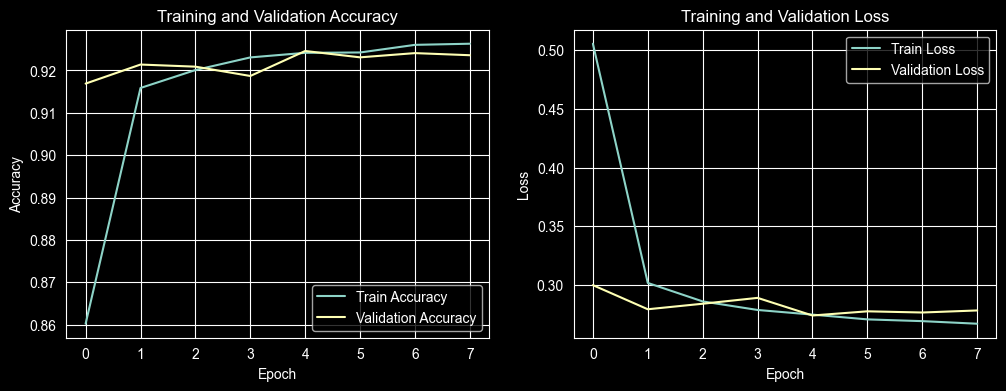

In [16]:
# Plot the training and validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

Compare the simple MLP to a SVM, or simple Logistic Regression model on the same dataset to see the difference in performance. You can use scikit-learn for this purpose.

In [21]:
from sklearn.svm import SVC

# Flatten the images for SVM
X_train_flat = X_train.reshape(X_train.shape[0], -1)[:500]
y_train_flat = y_train[:500]

# take only 500 example since it will take too much time to trina
X_test_flat = X_test.reshape(X_test.shape[0], -1)[:100]
y_test = y_test[:100]

# Train a simple SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_flat, y_train_flat)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
# Evaluate the SVM model
svm_pred = svm_model.predict(X_test_flat)

In [23]:
from sklearn.metrics import accuracy_score
svm_acc = accuracy_score(y_test, svm_pred)
print(f'SVM Test Accuracy: {svm_acc:.4f}')

SVM Test Accuracy: 0.9000
